In [1]:
from dislocations import *

In [2]:
n_points = 1000

xlim = (-15, 41)  
ylim = (-2, 27) 
figsize = (15, 7.5)
linewidth = 2.5
gp_offset = 30

name = "example_1"

# Eksperymenty

### Konfiguracja pierwotna

Tworzymy strukturę przechowującą siatkę krystalograficzną.

In [3]:
l0 = wzt.generate.create_lattice(
    dimensions=(13, 10, 1),  # (nx, ny, nz)
    cell="B4_GaN",
)


d1 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    # Położenie rdzenia dyslokacji
    position=[3.190+0.8+6*l0.cell.dimensions[0], 10, 7.5],
    # position=[4.01, 3.17, 7.5],
    # Płaszczyzna
    plane=(0, 0, 1),
    # Etykieta (tylko do prezentacji)
    label="$d_1$",
    # Kolor (tylko do prezentacji)
    color="brown"
)

# %matplotlib widget
# ax.set_title("Initial configuration")

In [4]:
log0 = displace(
    crystal=l0,
    dislocations=[], 
    d_n=d1,
    n_iters=1,
    n_points=n_points,
)

u0 = log0.last_u_atoms
last_d_state = log0.last_d_state

# Przesuń atomy
l1 = l0.translate(u0)
l1 = wzt.generate.update_bonds(l1, tolerance=0.45)

gp margin: 45
gp margin: 45
Step: 998on path: 259

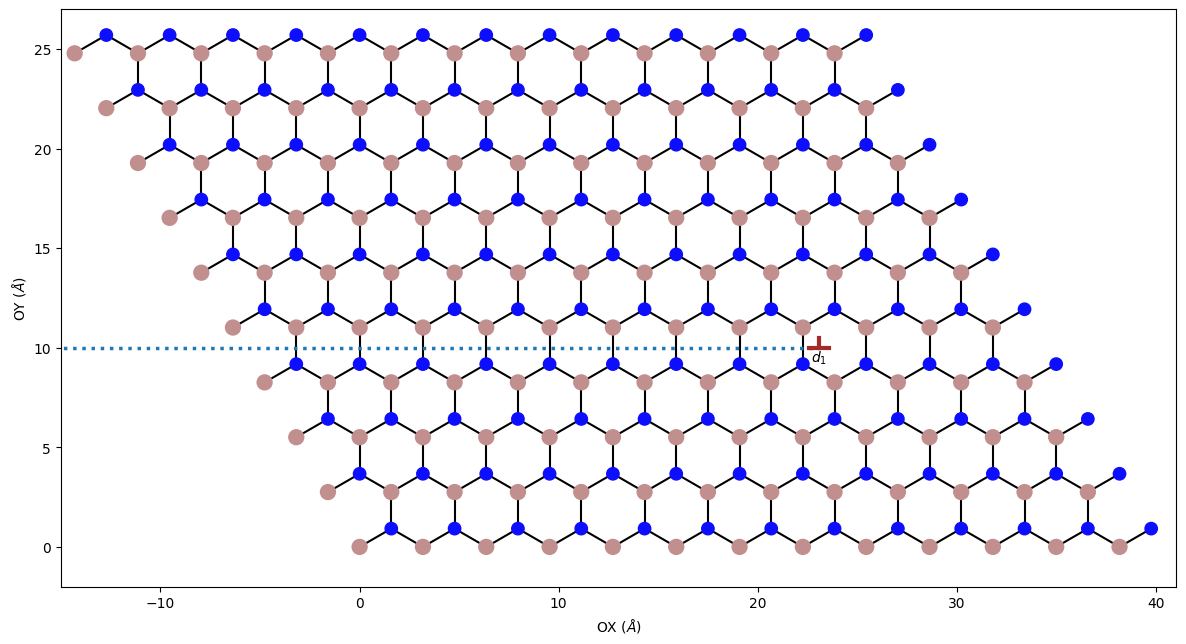

In [5]:
# Before
fig, ax = wzt.visualization.plot_atoms_2d(l0, xlim=xlim, ylim=ylim, figsize=figsize)

for d in [d1]:
    wzt.visualization.display_tee_2d(ax, d, scale=0.5, cell=l0.cell)
    
ax.plot(log0.last_glide_planes[0][:, 0], log0.last_glide_planes[0][:, 1], linestyle="dotted", label="$d_1$", linewidth=linewidth)

fig.savefig(f"{name}_1st_dislocation_before.svg", format="svg", bbox_inches="tight")

In [6]:
# After
gp_copy = log0.last_glide_planes[0].copy() + 0.1 # [A]

# Displace one more time, just to move the gliding plane
tmp_log0 = displace(
    crystal=l0,
    dislocations=[], 
    d_n=d1,
    n_iters=1,
    n_points=n_points,
    points=[gp_copy]
)

d1_gp = tmp_log0.points[-1][-1]

gp margin: 45
gp margin: 45
Step: 998on path: 460

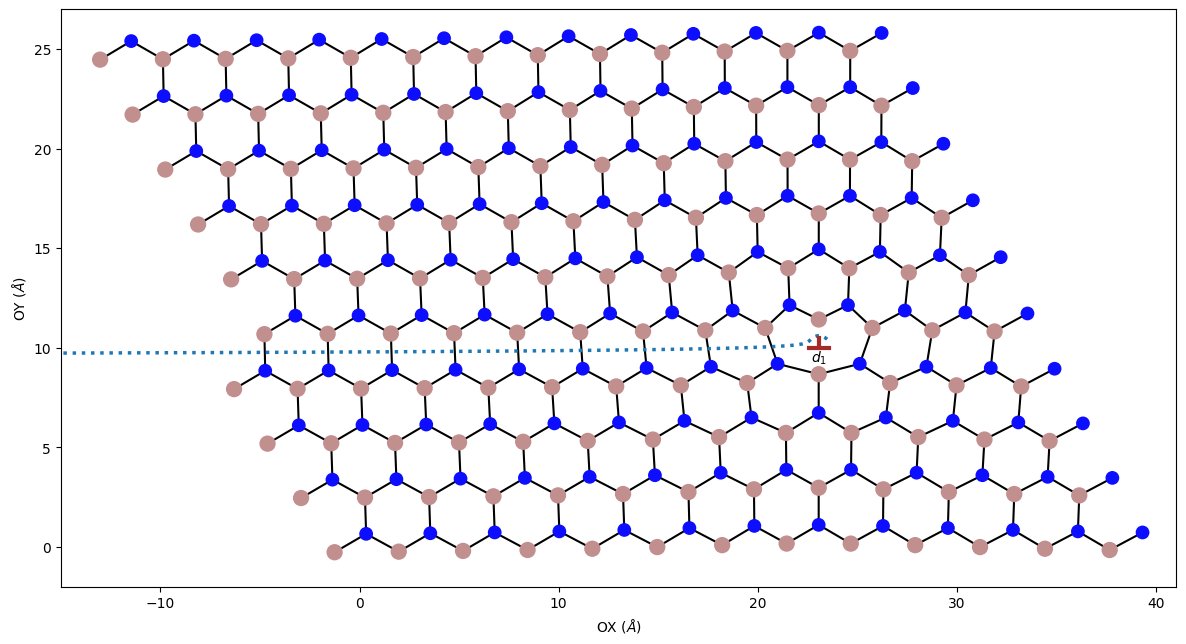

In [7]:
fig, ax = wzt.visualization.plot_atoms_2d(l1, xlim=xlim, ylim=ylim, figsize=figsize)

for d in last_d_state.ds:
    wzt.visualization.display_tee_2d(ax, d, scale=0.5, cell=l0.cell)
    
ax.plot(d1_gp[:, 0], d1_gp[:, 1], linestyle="dotted", label="$d_1$", linewidth=linewidth)

fig.savefig(f"{name}_1st_dislocation_after.svg", format="svg", bbox_inches="tight")

## Druga dyslokacja

In [8]:
d2 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    position=[2.35, 9.66, 0], # np.asarray(last_d_state.ds[0].position)+np.asarray([-5*l0.cell.dimensions[1], 0.0, 0.0]),
    plane=(0, 0, 1),
    label="$d_2$",
    color="brown"
)

log1 = displace(
    crystal=l1,
    dislocations=log0.last_d_state.ds, 
    d_n=d2,
    n_iters=1,
    n_points=n_points,
)

u1 = log1.last_u_atoms
last_d_state = log1.last_d_state

# Przesuń atomy
l2 = l1.translate(u1)
# Zaktualizuj wiązania
l2 = wzt.generate.update_bonds(l2, tolerance=0.45)

gp margin: 45
gp margin: 45
gp margin: 45ath: 0
gp margin: 45
Step: 998on path: 259

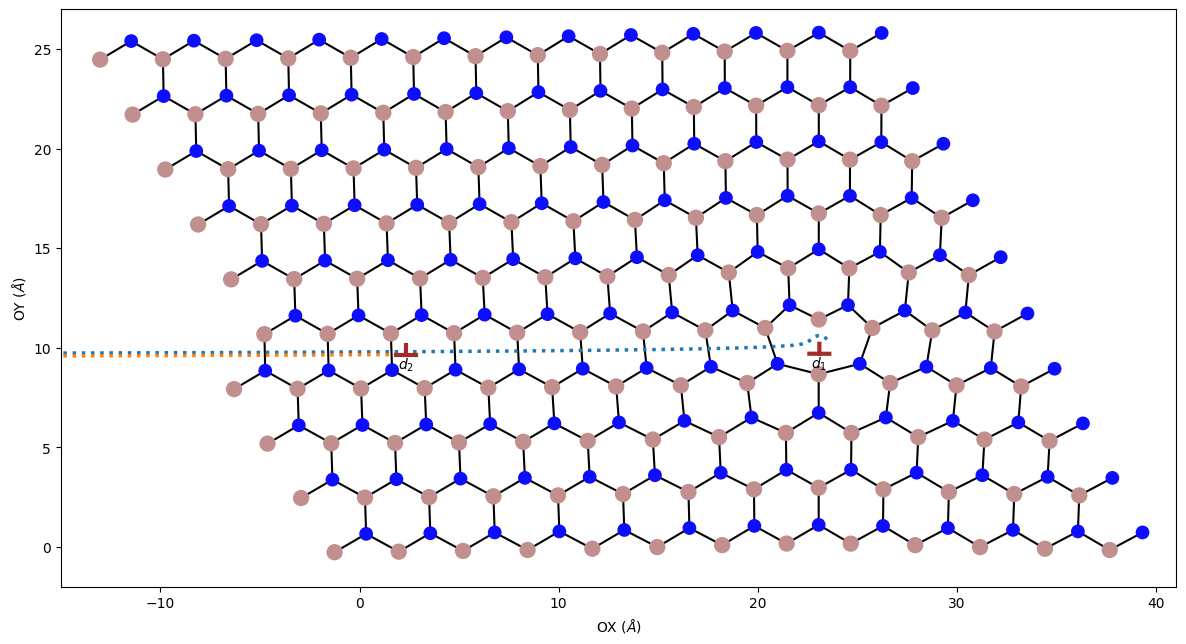

In [9]:
# Before
fig, ax = wzt.visualization.plot_atoms_2d(l1, xlim=xlim, ylim=ylim, figsize=figsize)

for d in last_d_state.ds[:-1] + [d2]:
    wzt.visualization.display_tee_2d(ax, d, scale=0.5, cell=l0.cell)
    
ax.plot(d1_gp[:, 0], d1_gp[:, 1], linestyle="dotted", label="$d_1$", linewidth=linewidth)
ax.plot(log1.last_glide_planes[1][:, 0], log1.last_glide_planes[1][:, 1], linestyle="dotted", label="$d_2$", linewidth=linewidth)

fig.savefig(f"{name}_2nd_dislocation_before.svg", format="svg", bbox_inches="tight")

gp margin: 45
gp margin: 45
gp margin: 45ath: 0
gp margin: 45
Step: 998on path: 466

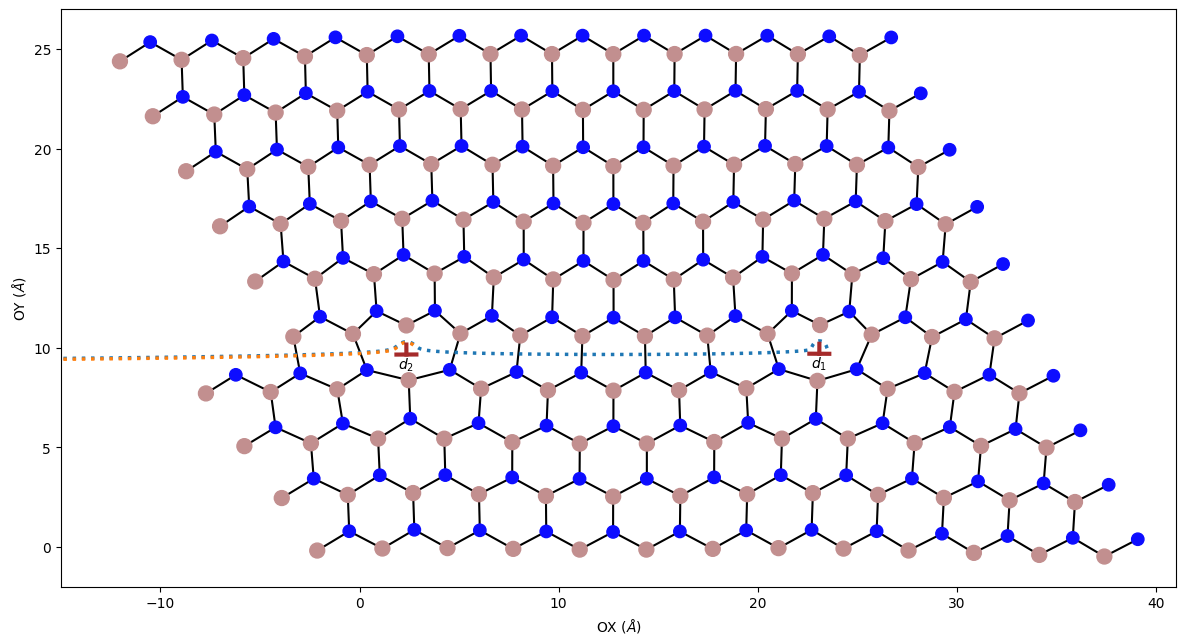

In [10]:
# After
gp_copy = log1.last_glide_planes[-1].copy() + 0.1 # [A]

# Displace one more time, just to move the gliding plane of the last dislocation
tmp_log1 = displace(
    crystal=l1,
    dislocations=log0.last_d_state.ds, 
    d_n=d2,
    n_iters=1,
    n_points=n_points,
    points=[d1_gp, gp_copy]
)

d1_gp_after_d2 = tmp_log1.points[-1][0]
d2_gp = tmp_log1.points[-1][-1]

fig, ax = wzt.visualization.plot_atoms_2d(l2, xlim=xlim, ylim=ylim, figsize=figsize)

for d in last_d_state.ds:
    wzt.visualization.display_tee_2d(ax, d, scale=0.5, cell=l0.cell)
    
ax.plot(d1_gp_after_d2[:, 0], d1_gp_after_d2[:, 1], linestyle="dotted", label="$d_1$", linewidth=linewidth)
ax.plot(d2_gp[:, 0], d2_gp[:, 1], linestyle="dotted", label="$d_2$", linewidth=linewidth)

fig.savefig(f"{name}_2nd_dislocation_after.svg", format="svg", bbox_inches="tight")

## Trzecia dyslokacja

In [11]:
d3 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[0, 1, 0],
    position=[8.53, 17.61, 0],
    # position=[2.31, 17.61, 0],
    plane=(0, 0, 1),
    label="$d_3$",
    color="brown"
)

log2 = displace(
    crystal=l2,
    dislocations=log1.last_d_state.ds, 
    d_n=d3,
    n_iters=1,
    n_points=n_points,
    points=log1.last_glide_planes
)

u2 = log2.last_u_atoms
last_d_state = log2.last_d_state

# Przesuń atomy
l3 = l2.translate(u2)
# Zaktualizuj wiązania
l3 = wzt.generate.update_bonds(l3, tolerance=0.45)

gp margin: 45
gp margin: 45
gp margin: 45
gp margin: 45ath: 0
gp margin: 45
gp margin: 45
Step: 998on path: 466

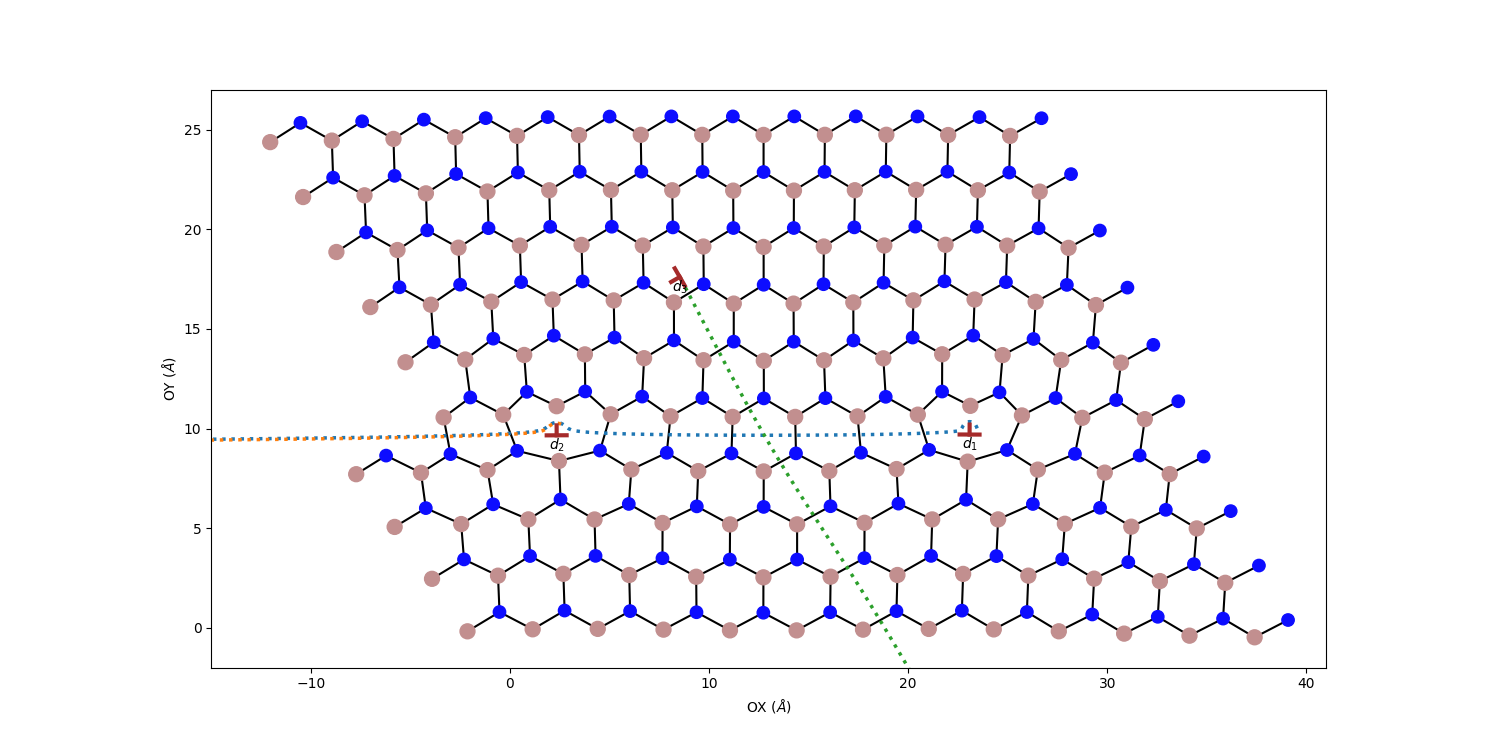

In [12]:
%matplotlib widget

fig, ax = wzt.visualization.plot_atoms_2d(l2, xlim=xlim, ylim=ylim, figsize=figsize)

for d in log1.last_d_state.ds + [d3]:
    wzt.visualization.display_tee_2d(ax, d, scale=0.5, cell=l0.cell)
    
ax.plot(d1_gp_after_d2[:, 0], d1_gp_after_d2[:, 1], linestyle="dotted", label="$d_1$", linewidth=linewidth)
ax.plot(d2_gp[:-20, 0], d2_gp[:-20, 1], linestyle="dotted", label="$d_2$", linewidth=linewidth)
ax.plot(log2.last_glide_planes[-1][:, 0], log2.last_glide_planes[-1][:, 1], linestyle="dotted", label="$d_3$", linewidth=linewidth)

fig.savefig(f"{name}_3rd_dislocation_before.svg", format="svg", bbox_inches="tight")

In [13]:
# After
gp_copy = log2.last_glide_planes[-1].copy() # [A]
gp_copy[:, 1] += 0.1

# Displace one more time, just to move the gliding plane of the last dislocation
tmp_log2 = displace(
    crystal=l2,
    dislocations=log1.last_d_state.ds, 
    d_n=d3,
    n_iters=1,
    n_points=n_points,
    points=[d1_gp_after_d2, d2_gp, gp_copy]
)

gp margin: 45
gp margin: 45
gp margin: 45
gp margin: 45ath: 0
gp margin: 45
gp margin: 45
Step: 998on path: 473

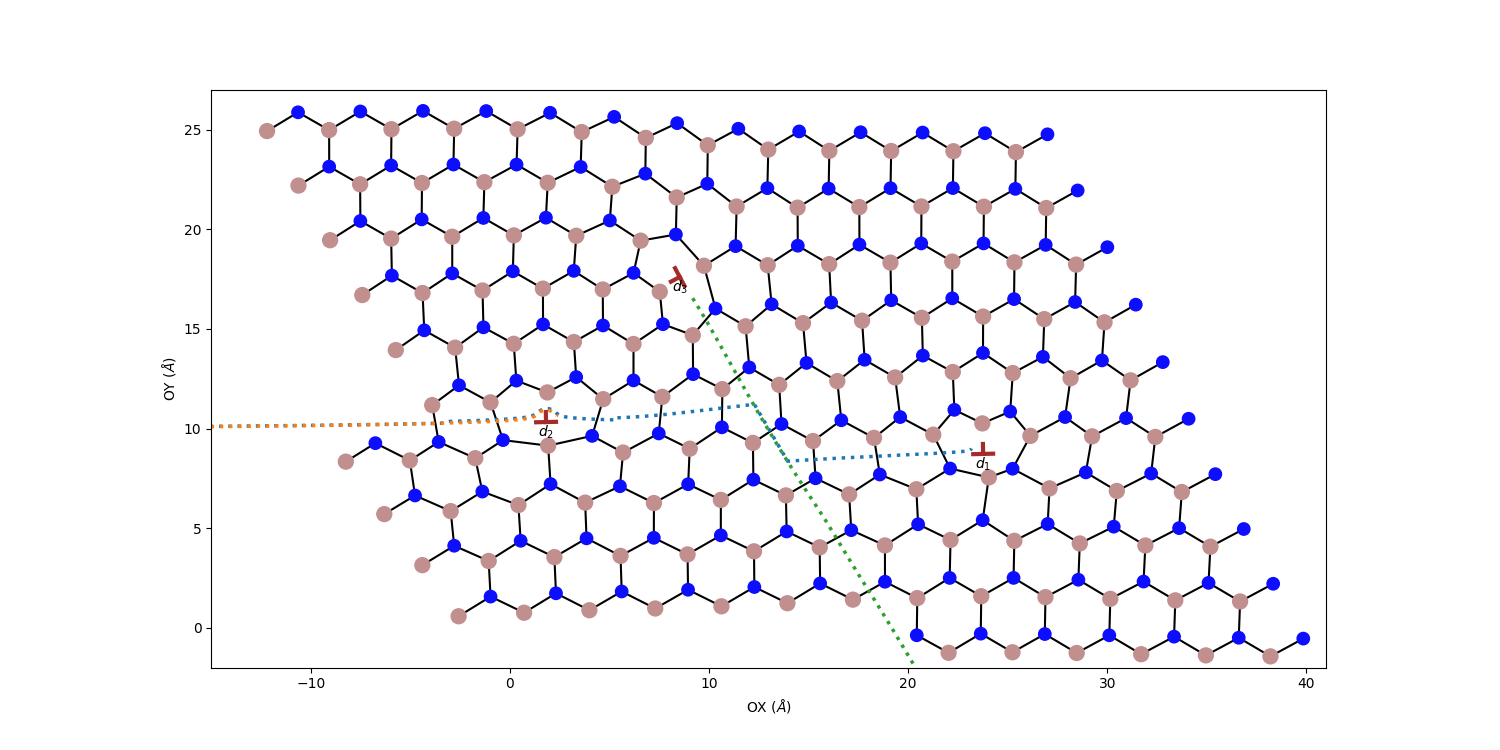

In [15]:
# %matplotlib widget
last_d_state = log2.last_d_state
fig, ax = wzt.visualization.plot_atoms_2d(l3, xlim=xlim, ylim=ylim, figsize=figsize)

for d in last_d_state.ds: 
    wzt.visualization.display_tee_2d(ax, d, scale=0.5) 
    
# d1
d1_offset = log2.last_d_state.ds[0].position-log1.last_d_state.ds[0].position
d1_offset = d1_offset.squeeze()

# d1_glide_plane = log2.points[-1][0].copy()
d1_glide_plane = tmp_log2.points[-1][0].copy()
d2_glide_plane = tmp_log2.points[-1][1].copy()
d3_glide_plane = tmp_log2.points[-1][-1].copy()

# Replace the distorted part of d1_gp above the d2 (it's too close to d2 ...)
d1_glide_plane[-300:-200, 0] = d1_gp_after_d2[-300:-200, 0] - 0.3
d1_glide_plane[-300:-200, 1] = d1_gp_after_d2[-300:-200, 1] + 0.7

# # Remove points close to the d1 (inaccuracies in the displacement calculations close to the dislocation core)
# d1_glide_plane = d1_glide_plane[510:-20, :]
# old_glide_plane = log1.last_glide_planes[0].copy()
# old_glide_plane[:, 1] += 0.7
# old_glide_plane[:, 0] += 0.1

# d1_glide_plane = np.concatenate((old_glide_plane[:500], d1_glide_plane), axis=0)
# d1_glide_plane[-1, :] = last_d_state.ds[0].position
ax.plot(d1_glide_plane[:-gp_offset, 0]-0.2, d1_glide_plane[:-gp_offset, 1], linestyle="dotted", linewidth=linewidth)


# d2
d2_offset = log2.last_d_state.ds[1].position-log1.last_d_state.ds[1].position
d2_offset = d2_offset.squeeze()
ax.plot(tmp_log1.points[-1][-1][:, 0]+d2_offset[0], tmp_log1.points[-1][-1][:, 1]+d2_offset[1], linestyle="dotted", linewidth=linewidth)

# d3
d3_gp = tmp_log2.points[-1][-1]
ax.plot(d3_glide_plane[10:-50, 0], d3_glide_plane[10:-50, 1], linestyle="dotted", linewidth=linewidth)
fig.savefig(f"{name}_3rd_dislocation_after.svg", format="svg", bbox_inches="tight")